# Introduction aux graphes de données

Ce notebook ne nécessite aucune connaissance en mathématiques ou en informatique.  
Chaque concept est introduit par une analogie du quotidien, avant de voir comment l'appliquer à un réseau de paiements.

---

## Table des matières

1. [Le graphe, c'est quoi concrètement ?](#partie-1)
2. [Comment naviguer dans un réseau ?](#partie-2)
3. [Qui est important dans le réseau ?](#partie-3)
4. [Qui forme des clans ?](#partie-4)
5. [Comment une machine "voit" un réseau ?](#partie-5)
6. [Détecter ce qui est bizarre](#partie-6)
7. [Application : réseau de paiements](#partie-7)

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.ensemble import IsolationForest
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

---

# <a name="partie-1"></a> 1. Le graphe, c'est quoi concrètement ?

## L'idée de base

Un graphe, c'est simplement une façon de représenter **des choses et les liens entre elles**.

Vous en utilisez tous les jours sans le savoir :

| Ce que vous voyez | Les "choses" (nœuds) | Les "liens" (arêtes) |
|---|---|---|
| Plan du métro | Stations | Lignes |
| Réseau d'amis | Personnes | Amitiés |
| Internet | Pages web | Liens hypertextes |
| Réseau de paiements | Clients / Fournisseurs | Transactions |

En langage graphe, on appelle ces "choses" des **nœuds** et ces "liens" des **arêtes**.

---

### Exemple 1 — Un réseau d'amis (liens sans direction)

Si Alice et Bob sont amis, la relation est **symétrique** : Alice est amie avec Bob, Bob est ami avec Alice. On parle de **graphe non-dirigé**.

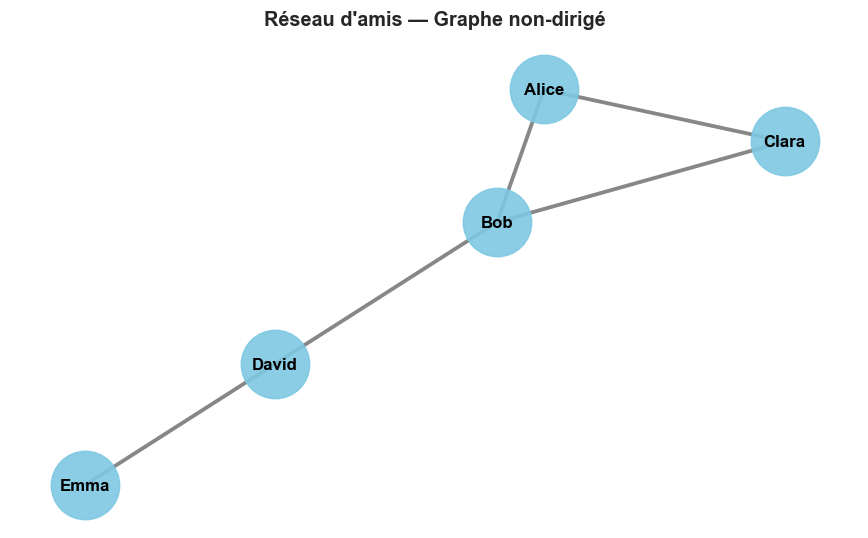

Nombre de personnes (nœuds) : 5
Nombre d'amitiés (arêtes)   : 5


In [2]:
# Réseau d'amis
G_amis = nx.Graph()
amis = ['Alice', 'Bob', 'Clara', 'David', 'Emma']
liens = [('Alice', 'Bob'), ('Alice', 'Clara'), ('Bob', 'Clara'), ('Bob', 'David'), ('David', 'Emma')]

G_amis.add_nodes_from(amis)
G_amis.add_edges_from(liens)

plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G_amis, seed=7)
nx.draw_networkx_nodes(G_amis, pos, node_size=2000, node_color='#7EC8E3', alpha=0.9)
nx.draw_networkx_labels(G_amis, pos, font_size=11, font_weight='bold')
nx.draw_networkx_edges(G_amis, pos, width=2.5, alpha=0.7, edge_color='#555555')
plt.title("Réseau d'amis — Graphe non-dirigé", fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Nombre de personnes (nœuds) : {G_amis.number_of_nodes()}")
print(f"Nombre d'amitiés (arêtes)   : {G_amis.number_of_edges()}")

### Exemple 2 — Des paiements (liens avec direction)

Un paiement n'est pas symétrique : c'est **A qui paie B**, pas l'inverse.  
On représente ça avec une flèche. On parle de **graphe dirigé**.

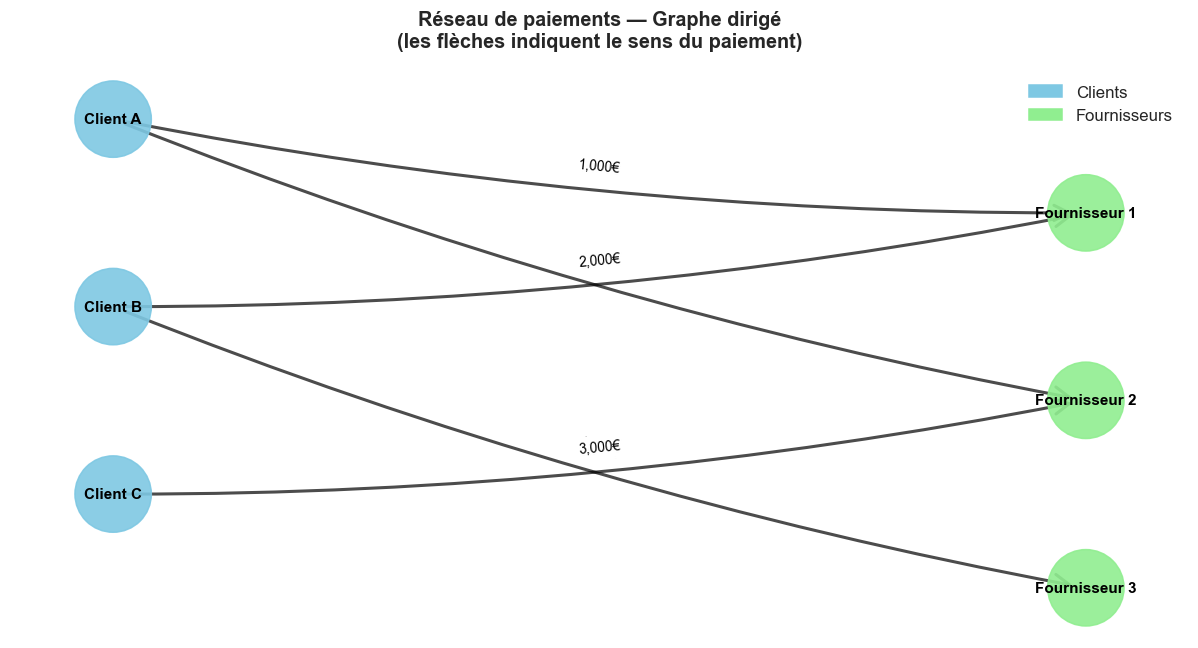

Ce qu'on voit d'un coup d'œil :
  → Fournisseur 1 reçoit de deux clients (A et B) : c'est un acteur central
  → Client C ne paie qu'un seul fournisseur : relation exclusive
  → Client A est le plus diversifié : il paie deux fournisseurs différents


In [3]:
# Réseau de paiements simple
G_paiements = nx.DiGraph()

clients = ['Client A', 'Client B', 'Client C']
fournisseurs = ['Fournisseur 1', 'Fournisseur 2', 'Fournisseur 3']

transactions = [
    ('Client A', 'Fournisseur 1', 1000),
    ('Client A', 'Fournisseur 2', 500),
    ('Client B', 'Fournisseur 1', 2000),
    ('Client B', 'Fournisseur 3', 1500),
    ('Client C', 'Fournisseur 2', 3000),
]

for src, dst, montant in transactions:
    G_paiements.add_edge(src, dst, weight=montant)

plt.figure(figsize=(11, 6))

# Positionner clients à gauche, fournisseurs à droite
pos = {}
for i, c in enumerate(clients):
    pos[c] = (-1, 1 - i)
for i, f in enumerate(fournisseurs):
    pos[f] = (1, 0.5 - i)

node_colors = ['#7EC8E3' if n in clients else '#90EE90' for n in G_paiements.nodes()]
nx.draw_networkx_nodes(G_paiements, pos, node_size=2500, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G_paiements, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_paiements, pos, width=2, alpha=0.7, arrowsize=25,
                       connectionstyle='arc3,rad=0.05', arrowstyle='->')
edge_labels = {(u, v): f"{d['weight']:,}€" for u, v, d in G_paiements.edges(data=True)}
nx.draw_networkx_edge_labels(G_paiements, pos, edge_labels, font_size=9)

# Légende
patch_c = mpatches.Patch(color='#7EC8E3', label='Clients')
patch_f = mpatches.Patch(color='#90EE90', label='Fournisseurs')
plt.legend(handles=[patch_c, patch_f], loc='upper right', fontsize=11)

plt.title("Réseau de paiements — Graphe dirigé\n(les flèches indiquent le sens du paiement)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Ce qu'on voit d'un coup d'œil :")
print("  → Fournisseur 1 reçoit de deux clients (A et B) : c'est un acteur central")
print("  → Client C ne paie qu'un seul fournisseur : relation exclusive")
print("  → Client A est le plus diversifié : il paie deux fournisseurs différents")

### Exemple 3 — Les montants comptent aussi (graphe pondéré)

On peut ajouter une **valeur** sur chaque lien — par exemple le montant d'une transaction.  
Plus le lien est épais, plus le montant est élevé. On parle de **graphe pondéré**.

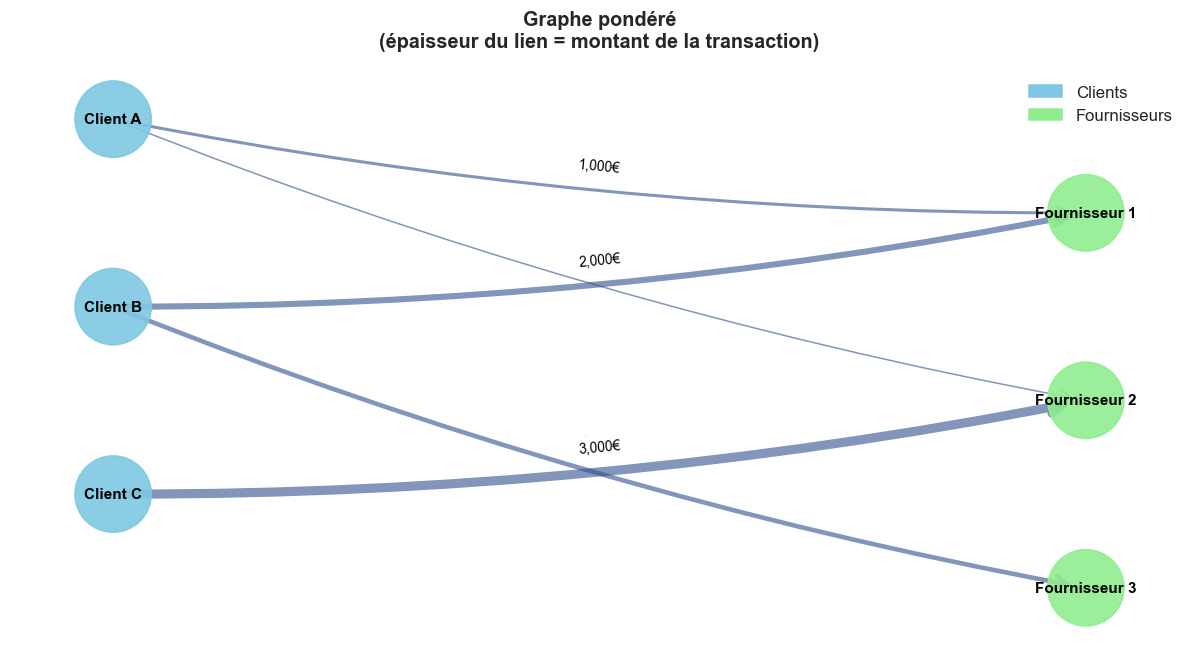

Ce que l'épaisseur révèle :
  → Client C → Fournisseur 2 (3 000€) : lien le plus épais = transaction la plus importante
  → Client A → Fournisseur 2 (500€) : lien fin = petite transaction


In [4]:
plt.figure(figsize=(11, 6))

# Épaisseur proportionnelle au montant
weights = [G_paiements[u][v]['weight'] / 500 for u, v in G_paiements.edges()]

node_colors = ['#7EC8E3' if n in clients else '#90EE90' for n in G_paiements.nodes()]
nx.draw_networkx_nodes(G_paiements, pos, node_size=2500, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G_paiements, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_paiements, pos, width=weights, alpha=0.6, arrowsize=20,
                       connectionstyle='arc3,rad=0.05', edge_color='#2F4F8F', arrowstyle='->')
nx.draw_networkx_edge_labels(G_paiements, pos, edge_labels, font_size=9)

plt.legend(handles=[patch_c, patch_f], loc='upper right', fontsize=11)
plt.title("Graphe pondéré\n(épaisseur du lien = montant de la transaction)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Ce que l'épaisseur révèle :")
print("  → Client C → Fournisseur 2 (3 000€) : lien le plus épais = transaction la plus importante")
print("  → Client A → Fournisseur 2 (500€) : lien fin = petite transaction")

### À retenir

> **Un graphe = des nœuds + des arêtes.**  
> Les arêtes peuvent avoir une direction (paiement) et une valeur (montant).  
> La visualisation permet de voir d'un coup d'œil des patterns qu'un tableau de données cacherait.

---

# <a name="partie-2"></a> 2. Comment naviguer dans un réseau ?

## L'analogie du GPS

Quand vous utilisez Google Maps, vous lui demandez : "Comment aller de A à B le plus vite possible ?"

Dans un graphe, on pose la même question : **quel est le chemin le plus court entre deux nœuds ?**

Dans un réseau de paiements, ça répond à : *"En combien d'intermédiaires peut-on relier ce client à cet autre client ?"*

### Pourquoi c'est utile ?
- **Détecter des connexions cachées** : deux clients qui semblent indépendants mais sont reliés via 2 fournisseurs communs
- **Mesurer la proximité** dans le réseau : des acteurs proches se "connaissent" indirectement
- **Identifier des clusters isolés** : des groupes sans aucun lien entre eux

Chemin le plus court entre Alice et David :
  Alice → Bob → David (2 étapes)


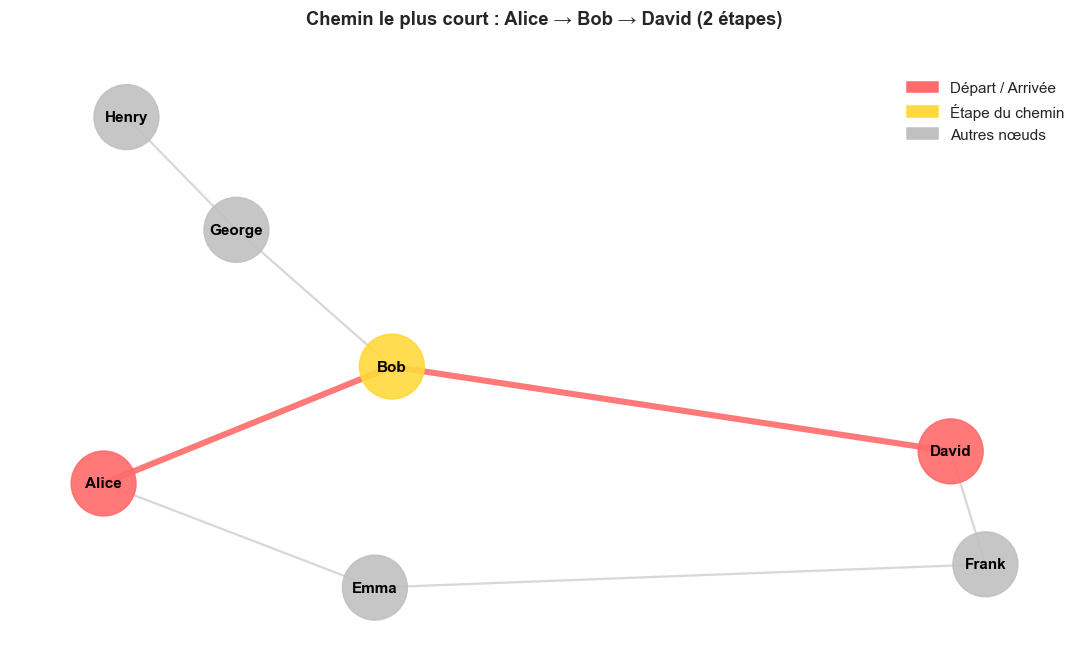

In [5]:
# Construire un réseau pour illustrer les chemins
G_nav = nx.Graph()
liens_nav = [
    ('Alice', 'Bob'), ('Bob', 'David'),                     # Chemin court : 2 étapes
    ('Alice', 'Emma'), ('Emma', 'Frank'), ('Frank', 'David'), # Chemin long  : 3 étapes
    ('Bob', 'George'), ('George', 'Henry'),                  # Nœuds hors chemin
]
G_nav.add_edges_from(liens_nav)

pos_nav = nx.spring_layout(G_nav, seed=12)

# Trouver le chemin le plus court entre Alice et David
chemin = nx.shortest_path(G_nav, 'Alice', 'David')
print(f"Chemin le plus court entre Alice et David :")
print(f"  {' → '.join(chemin)} ({len(chemin)-1} étapes)")

# Arêtes du chemin retenu
aretes_chemin = [(chemin[i], chemin[i+1]) for i in range(len(chemin)-1)]
aretes_autres  = [e for e in G_nav.edges()
                  if e not in aretes_chemin and (e[1], e[0]) not in aretes_chemin]

# Colorier les nœuds
couleurs_noeuds = []
for n in G_nav.nodes():
    if n in ('Alice', 'David'):
        couleurs_noeuds.append('#FF6B6B')
    elif n in chemin:
        couleurs_noeuds.append('#FFD93D')
    else:
        couleurs_noeuds.append('#C0C0C0')

plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(G_nav, pos_nav, node_size=1800, node_color=couleurs_noeuds, alpha=0.9)
nx.draw_networkx_labels(G_nav, pos_nav, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_nav, pos_nav, edgelist=aretes_autres,
                       width=1.5, alpha=0.3, edge_color='gray')
nx.draw_networkx_edges(G_nav, pos_nav, edgelist=aretes_chemin,
                       width=4, alpha=0.9, edge_color='#FF6B6B')

rouge = mpatches.Patch(color='#FF6B6B', label='Départ / Arrivée')
jaune = mpatches.Patch(color='#FFD93D', label='Étape du chemin')
gris  = mpatches.Patch(color='#C0C0C0', label='Autres nœuds')
plt.legend(handles=[rouge, jaune, gris], loc='upper right', fontsize=10)

plt.title("Chemin le plus court : Alice → Bob → David (2 étapes)\n",
          fontsize=12, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### Composantes connexes — "Est-ce que tout le monde est connecté ?"

Parfois, un réseau est **fragmenté** : certains groupes n'ont aucun lien avec le reste.  
On appelle ces groupes isolés des **composantes connexes**.

Dans un réseau de paiements, des groupes complètement isolés peuvent indiquer :
- Des entités qui n'interagissent jamais entre elles (normal)
- Ou au contraire, des cellules organisées qui évitent tout contact avec le réseau principal (suspect)

Nombre de groupes (composantes connexes) : 4
  Groupe 1 : ['A', 'B', 'C']
  Groupe 2 : ['D', 'E', 'F']
  Groupe 3 : ['G', 'H']
  Groupe 4 : ['I']


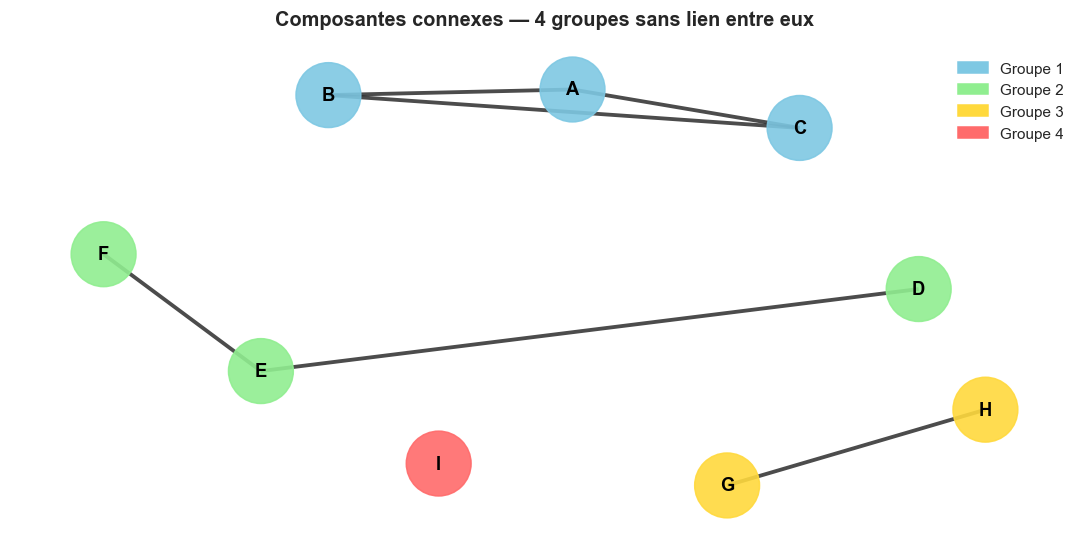

In [6]:
# Réseau avec plusieurs groupes isolés
G_comp = nx.Graph()
G_comp.add_edges_from([
    ('A', 'B'), ('B', 'C'), ('A', 'C'),          # Groupe 1
    ('D', 'E'), ('E', 'F'),                        # Groupe 2
    ('G', 'H'),                                    # Groupe 3
])
G_comp.add_node('I')                              # Groupe 4 : nœud isolé

composantes = list(nx.connected_components(G_comp))
print(f"Nombre de groupes (composantes connexes) : {len(composantes)}")
for i, comp in enumerate(composantes, 1):
    print(f"  Groupe {i} : {sorted(comp)}")

# Colorier chaque groupe différemment
couleurs_palette = ['#7EC8E3', '#90EE90', '#FFD93D', '#FF6B6B']
couleur_noeud = {}
for i, comp in enumerate(composantes):
    for n in comp:
        couleur_noeud[n] = couleurs_palette[i]

plt.figure(figsize=(10, 5))
pos_comp = nx.spring_layout(G_comp, seed=5, k=2)
colors = [couleur_noeud[n] for n in G_comp.nodes()]
nx.draw_networkx_nodes(G_comp, pos_comp, node_size=1800, node_color=colors, alpha=0.9)
nx.draw_networkx_labels(G_comp, pos_comp, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G_comp, pos_comp, width=2.5, alpha=0.7)

patches = [mpatches.Patch(color=couleurs_palette[i], label=f'Groupe {i+1}') for i in range(len(composantes))]
plt.legend(handles=patches, loc='upper right', fontsize=10)
plt.title("Composantes connexes — 4 groupes sans lien entre eux",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### À retenir

> **Naviguer dans un graphe, c'est répondre à "Qui peut atteindre qui, et en combien d'étapes ?"**  
> Les groupes isolés révèlent la structure cachée d'un réseau.

---

# <a name="partie-3"></a> 3. Qui est important dans le réseau ?

## L'idée

"Être important" dans un réseau peut vouloir dire plusieurs choses.  
Imaginez une ville :
- La gare centrale (tout le monde y passe) est importante **par son nombre de connexions**
- Un pont unique (seul moyen de passer d'un quartier à l'autre) est important **par sa position stratégique**
- La mairie (proche de tout) est importante **par sa proximité**
- Le maire (recommandé par des gens influents) est important **par sa réputation**

On a une mesure pour chaque cas.

---

### Mesure 1 — Degree : "Combien de connexions ?"
**Analogie** : popularité sur les réseaux sociaux. Plus vous avez d'amis, plus votre degré est élevé.

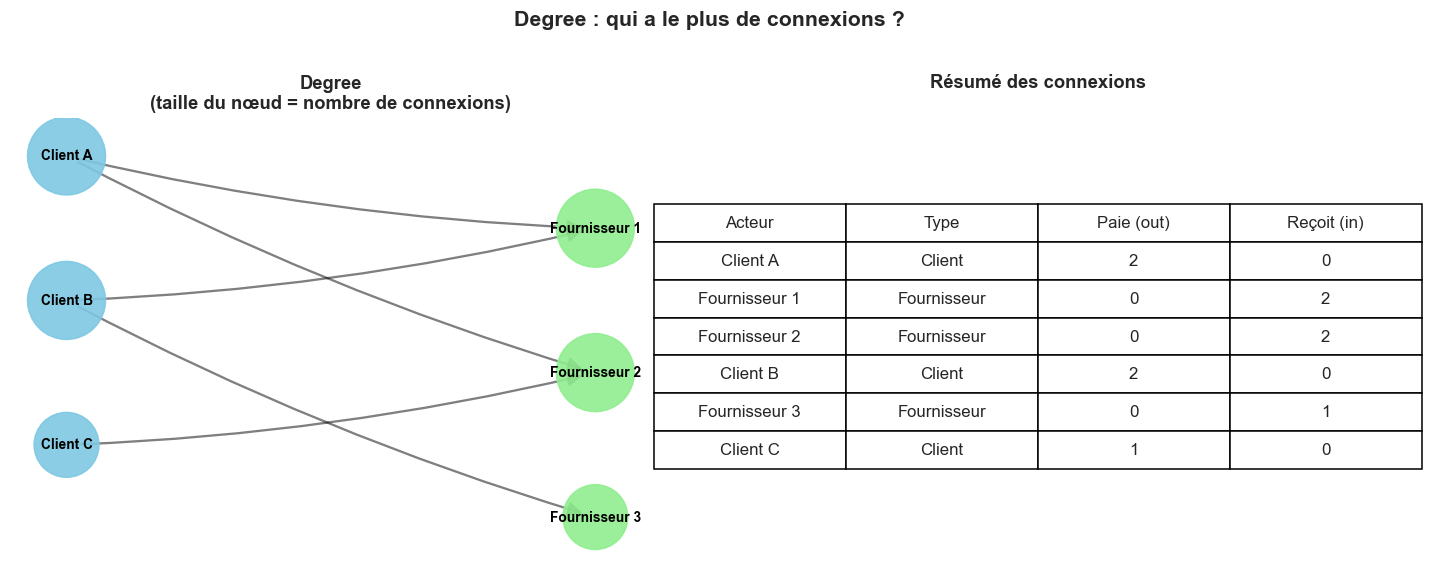

Lecture : Fournisseur 1 reçoit de 2 clients → acteur central côté fournisseurs


In [7]:
# Utiliser le réseau de paiements
G = G_paiements.copy()

# Degree : nombre de transactions reçues (in) ou envoyées (out)
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

df = pd.DataFrame({
    'Acteur': list(G.nodes()),
    'Type': ['Client' if n in clients else 'Fournisseur' for n in G.nodes()],
    'Paie (out)': [out_degree[n] for n in G.nodes()],
    'Reçoit (in)': [in_degree[n] for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique réseau avec taille proportionnelle au degree total
ax = axes[0]
degree_total = {n: in_degree[n] + out_degree[n] for n in G.nodes()}
sizes = [1000 + degree_total[n] * 800 for n in G.nodes()]
colors_nodes = ['#7EC8E3' if n in clients else '#90EE90' for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors_nodes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, arrowsize=20,
                       connectionstyle='arc3,rad=0.05', ax=ax)
ax.set_title("Degree\n(taille du nœud = nombre de connexions)", fontweight='bold')
ax.axis('off')

# Tableau
ax2 = axes[1]
ax2.axis('off')
table_data = df.values.tolist()
table = ax2.table(cellText=table_data, colLabels=df.columns,
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
ax2.set_title("Résumé des connexions", fontweight='bold', pad=20)

plt.suptitle("Degree : qui a le plus de connexions ?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Lecture : Fournisseur 1 reçoit de 2 clients → acteur central côté fournisseurs")

### Mesure 2 — Betweenness : "Le carrefour incontournable"

**Analogie** : Le Carrefour (le rond-point, pas le supermarché).  
Même si vous n'allez pas au carrefour, vous êtes obligé de le traverser pour aller d'un endroit à un autre.  

Un nœud avec un **betweenness élevé** est celui par lequel passent le plus de chemins dans le réseau.  
Si ce nœud disparaît, le réseau se fragmente.

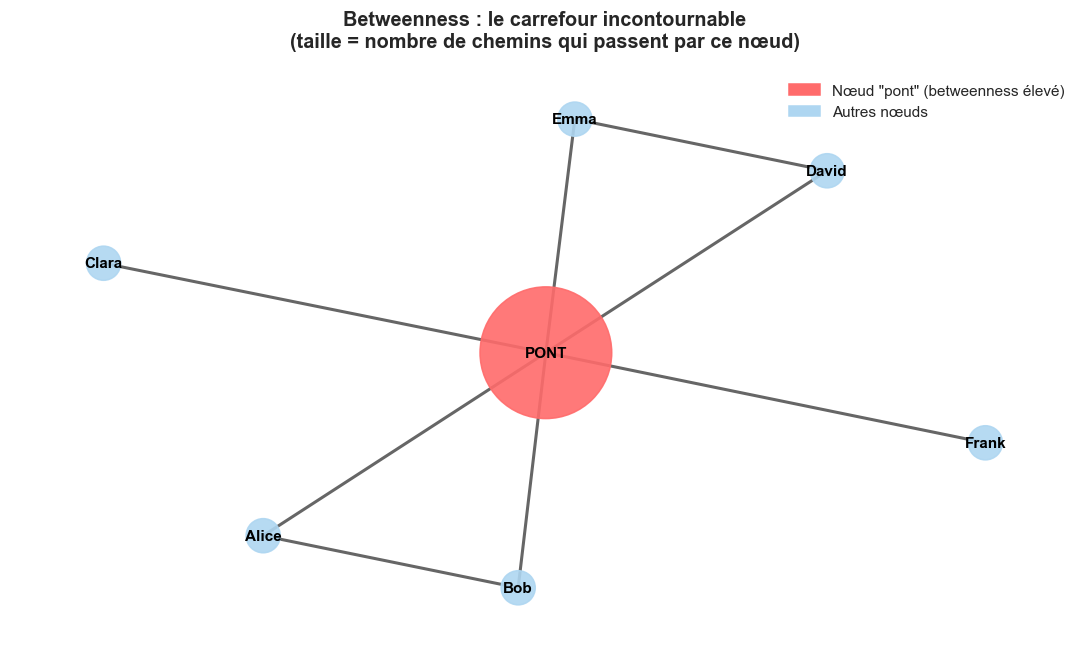

Scores de betweenness :
  PONT     : ██████████████████████████ (0.87)
  Alice    :  (0.00)
  Bob      :  (0.00)
  Clara    :  (0.00)
  David    :  (0.00)
  Emma     :  (0.00)
  Frank    :  (0.00)

Si 'PONT' disparaît, le réseau se coupe en deux parties qui ne peuvent plus communiquer.


In [8]:
# Réseau plus illustratif pour le betweenness
G_bet = nx.Graph()
G_bet.add_edges_from([
    ('Alice', 'PONT'), ('Bob', 'PONT'), ('Clara', 'PONT'),
    ('PONT', 'David'), ('PONT', 'Emma'), ('PONT', 'Frank'),
    ('Alice', 'Bob'),
    ('David', 'Emma'),
])

betweenness = nx.betweenness_centrality(G_bet)
pos_bet = nx.spring_layout(G_bet, seed=42)

plt.figure(figsize=(10, 6))
sizes = [500 + betweenness[n] * 8000 for n in G_bet.nodes()]
couleurs = ['#FF6B6B' if n == 'PONT' else '#AED6F1' for n in G_bet.nodes()]

nx.draw_networkx_nodes(G_bet, pos_bet, node_size=sizes, node_color=couleurs, alpha=0.9)
nx.draw_networkx_labels(G_bet, pos_bet, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_bet, pos_bet, width=2, alpha=0.6)

rouge = mpatches.Patch(color='#FF6B6B', label='Nœud "pont" (betweenness élevé)')
bleu  = mpatches.Patch(color='#AED6F1', label='Autres nœuds')
plt.legend(handles=[rouge, bleu], loc='upper right', fontsize=10)

plt.title("Betweenness : le carrefour incontournable\n"
          "(taille = nombre de chemins qui passent par ce nœud)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Scores de betweenness :")
for noeud, score in sorted(betweenness.items(), key=lambda x: -x[1]):
    barre = '█' * int(score * 30)
    print(f"  {noeud:8s} : {barre} ({score:.2f})")
print("\nSi 'PONT' disparaît, le réseau se coupe en deux parties qui ne peuvent plus communiquer.")

### Mesure 3 — PageRank : "La réputation par recommandation"

**Analogie** : C'est l'algorithme original de Google.  
Être recommandé par une célébrité vaut plus qu'être recommandé par des inconnus.

Un nœud a un **PageRank élevé** s'il reçoit des liens de nœuds qui sont eux-mêmes importants.  

Dans un réseau de paiements : un fournisseur payé par un **client lui-même très actif dans le réseau** (qui reçoit beaucoup de paiements d'autres acteurs importants) hérite de cette importance.

> ⚠️ À ne pas confondre avec le Degree : un fournisseur peut avoir peu de clients mais un PageRank élevé si ces clients sont eux-mêmes des acteurs centraux du réseau.

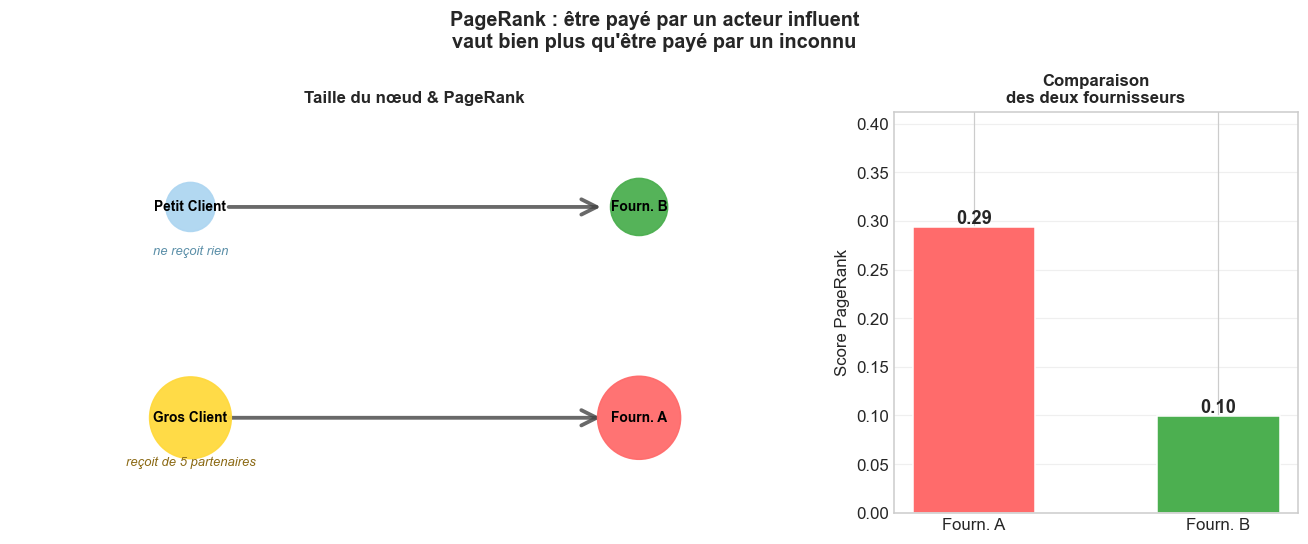

→ Fourn. A : 0.29  — son client est très connecté dans le réseau
→ Fourn. B : 0.10  — son client est isolé


In [9]:
pagerank = nx.pagerank(G_paiements)

# Réseau complet pour le calcul (5 sources rendent Gros Client influent)
G_pr = nx.DiGraph()
G_pr.add_edges_from([
    ('Source 1', 'Gros Client'), ('Source 2', 'Gros Client'), ('Source 3', 'Gros Client'),
    ('Source 4', 'Gros Client'), ('Source 5', 'Gros Client'),
    ('Gros Client', 'Fourn. A'),
    ('Petit Client', 'Fourn. B'),
])
pr_ex = nx.pagerank(G_pr)

# 4 nœuds dessinés, centrés dans l'axe
G_draw = nx.DiGraph()
G_draw.add_edges_from([('Gros Client', 'Fourn. A'), ('Petit Client', 'Fourn. B')])

pos_pr = {
    'Gros Client':  (0,  0),
    'Fourn. A':     (2,  0),
    'Petit Client': (0,  2),
    'Fourn. B':     (2,  2),
}
node_colors_pr = {
    'Gros Client':  '#FFD93D',
    'Fourn. A':     '#FF6B6B',
    'Petit Client': '#AED6F1',
    'Fourn. B':     '#4CAF50',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})

# --- Graphe ---
ax1 = axes[0]
sizes = [600 + pr_ex[n] * 8000 for n in G_draw.nodes()]
nx.draw_networkx_edges(G_draw, pos_pr, ax=ax1,
                       width=2.5, alpha=0.8, arrowsize=25, arrowstyle='->',
                       edge_color='#444444', min_source_margin=25, min_target_margin=25)
nx.draw_networkx_nodes(G_draw, pos_pr, ax=ax1,
                       node_color=[node_colors_pr[n] for n in G_draw.nodes()],
                       node_size=sizes, alpha=0.95)
nx.draw_networkx_labels(G_draw, pos_pr, ax=ax1, font_size=9, font_weight='bold')

# Texte sous chaque client, pas d'annotation avec flèche
ax1.text(0, -0.45, "reçoit de 5 partenaires", ha='center', fontsize=8.5,
         color='#8B6914', style='italic')
ax1.text(0,  1.55, "ne reçoit rien",          ha='center', fontsize=8.5,
         color='#5B8FA8', style='italic')

ax1.set_xlim(-0.8, 2.8)
ax1.set_ylim(-0.9, 2.9)
ax1.set_title("Taille du nœud & PageRank", fontweight='bold', fontsize=11)
ax1.axis('off')

# --- Bar chart ---
ax2 = axes[1]
fourn  = ['Fourn. A', 'Fourn. B']
scores = [pr_ex[f] for f in fourn]
bars   = ax2.bar(fourn, scores, color=['#FF6B6B', '#4CAF50'], width=0.5, edgecolor='white')
for bar, score in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{score:.2f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(scores) * 1.4)
ax2.set_ylabel('Score PageRank', fontsize=11)
ax2.set_title('Comparaison\ndes deux fournisseurs', fontweight='bold', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
ax2.tick_params(labelsize=11)

plt.suptitle("PageRank : être payé par un acteur influent\nvaut bien plus qu'être payé par un inconnu",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"→ Fourn. A : {pr_ex['Fourn. A']:.2f}  — son client est très connecté dans le réseau")
print(f"→ Fourn. B : {pr_ex['Fourn. B']:.2f}  — son client est isolé")

### Tableau récapitulatif des 4 mesures d'importance

| Mesure | Analogie | Question posée | Signal d'alerte |
|---|---|---|---|
| **Degree** | Popularité | Combien de connexions ? | Client qui multiplie soudainement les fournisseurs |
| **Betweenness** | Carrefour | Qui est incontournable ? | Intermédiaire qui connecte des groupes normalement séparés |
| **Closeness** | Proximité | Qui est au centre ? | Nouveau tiers qui devient très central très vite |
| **PageRank** | Réputation | Qui est recommandé par les importants ? | Gros paiement vers un tiers peu réputé |

---

# <a name="partie-4"></a> 4. Qui forme des clans ?

## L'analogie du lycée

Dans un lycée, les élèves forment naturellement des groupes : les sportifs, les geeks, les artistes...  
Ces groupes se créent **sans qu'on le décide** — ils émergent des affinités naturelles.

Un graphe fait pareil. On peut demander à l'algorithme : **"Trouve les groupes naturels dans ce réseau."**  
C'est ce qu'on appelle la **détection de communautés**.

### Pourquoi c'est crucial pour la fraude ?

Un **anneau de fraude** est un groupe de comptes qui transactionnent ensemble de façon coordonnée,  
mais sont présentés comme des entités indépendantes.  
La détection de communautés peut révéler ces structures cachées.

Communautés détectées automatiquement : 3
  Communauté 1 : ['C1', 'C2', 'C3', 'F1', 'F2']
  Communauté 2 : ['C4', 'C5', 'F3', 'F4']
  Communauté 3 : ['C6', 'C7', 'C8', 'F5']


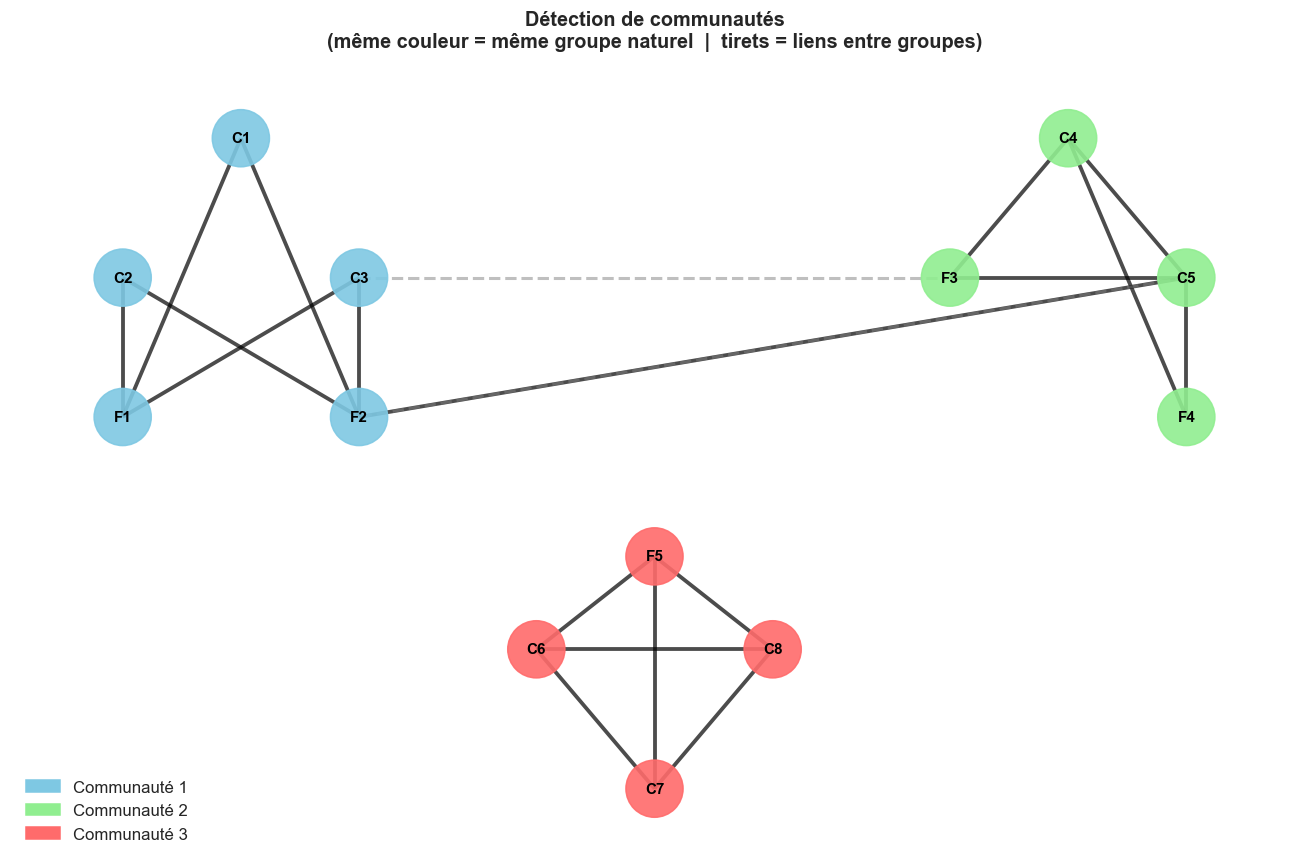

In [10]:
# Réseau avec des communautés naturelles
G_com = nx.Graph()

liens_g1 = [('C1','F1'), ('C2','F1'), ('C1','F2'), ('C3','F2'), ('C2','F2'), ('C3','F1')]
liens_g2 = [('C4','F3'), ('C5','F3'), ('C4','F4'), ('C5','F4'), ('C4','C5')]
liens_g3 = [('C6','F5'), ('C7','F5'), ('C8','F5'), ('C6','C7'), ('C7','C8'), ('C6','C8')]
liens_inter = [('C3','F3'), ('C5','F2')]

G_com.add_edges_from(liens_g1 + liens_g2 + liens_g3 + liens_inter)

from networkx.algorithms.community import greedy_modularity_communities
communautes = list(greedy_modularity_communities(G_com))

print(f"Communautés détectées automatiquement : {len(communautes)}")
for i, com in enumerate(communautes, 1):
    print(f"  Communauté {i} : {sorted(com)}")

# Positions manuelles : chaque communauté dans sa zone
pos_com = {
    # Communauté 1 — haut gauche
    'C1': (-3.5,  1.5), 'C2': (-4.5,  0), 'C3': (-2.5,  0),
    'F1': (-4.5, -1.5), 'F2': (-2.5, -1.5),
    # Communauté 2 — haut droite
    'C4': ( 3.5,  1.5), 'C5': ( 4.5,  0),
    'F3': ( 2.5,  0),   'F4': ( 4.5, -1.5),
    # Communauté 3 — bas centre
    'C6': (-1,   -4),   'C7': ( 0,   -5.5), 'C8': ( 1,   -4),
    'F5': ( 0,   -3),
}

palette = ['#7EC8E3', '#90EE90', '#FF6B6B']
couleur_map = {}
for i, com in enumerate(communautes):
    for n in com:
        couleur_map[n] = palette[i % len(palette)]

plt.figure(figsize=(12, 8))
node_colors_com = [couleur_map[n] for n in G_com.nodes()]

nx.draw_networkx_nodes(G_com, pos_com, node_size=1400, node_color=node_colors_com, alpha=0.9)
nx.draw_networkx_labels(G_com, pos_com, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_com, pos_com,
                       edgelist=[e for e in G_com.edges() if e not in liens_inter],
                       width=2.5, alpha=0.7)
nx.draw_networkx_edges(G_com, pos_com, edgelist=liens_inter,
                       width=2, alpha=0.5, edge_color='gray', style='dashed')

patches = [mpatches.Patch(color=palette[i], label=f'Communauté {i+1}') for i in range(len(communautes))]
plt.legend(handles=patches, loc='lower left', fontsize=11)
plt.title("Détection de communautés\n"
          "(même couleur = même groupe naturel  |  tirets = liens entre groupes)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### Application fraude : détecter un anneau de transactions coordonnées

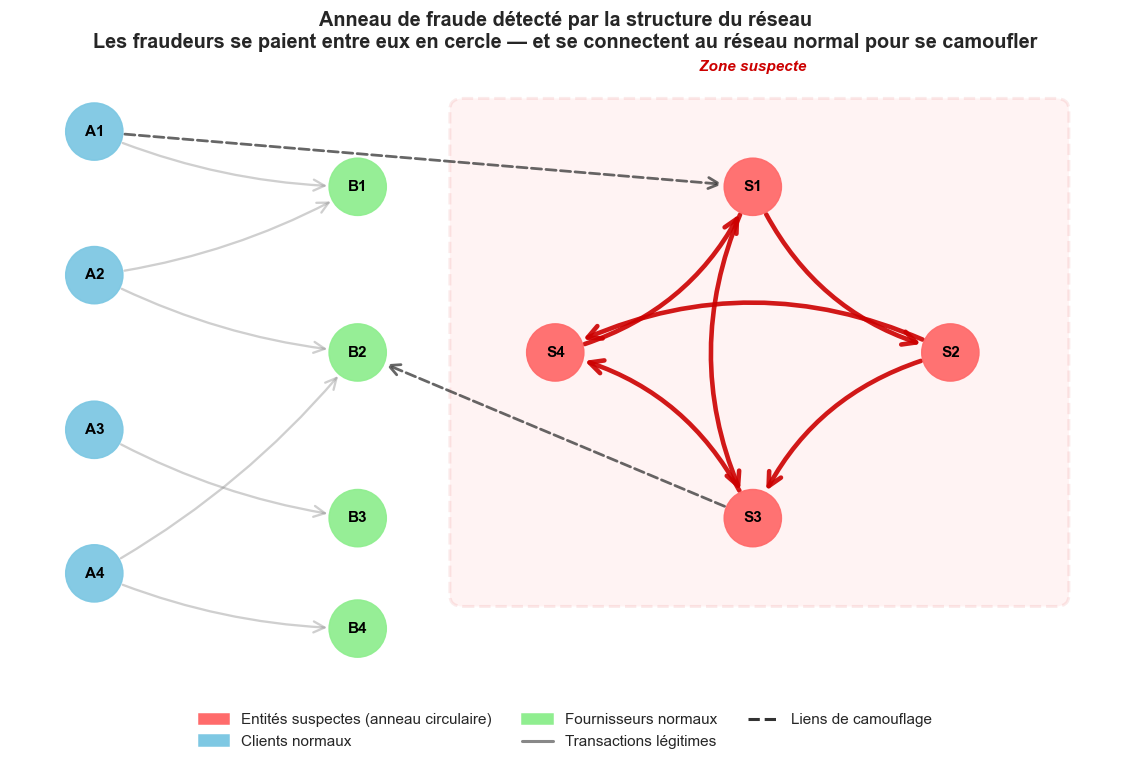

Signal d'alerte : dans un réseau de paiements légitimes,
les clients paient des fournisseurs — pas d'autres clients.
Des transactions circulaires entre entités = structure anormale.


In [11]:
import matplotlib.lines as mlines
from matplotlib.patches import FancyBboxPatch

G_fraude = nx.DiGraph()

normaux    = [('A1','B1'), ('A2','B1'), ('A2','B2'), ('A3','B3'), ('A4','B2'), ('A4','B4')]
suspects   = ['S1', 'S2', 'S3', 'S4']
anneau     = [('S1','S2'), ('S2','S3'), ('S3','S4'), ('S4','S1'),
              ('S1','S3'), ('S2','S4')]   # + diagonales → encore plus dense
camouflage = [('A1','S1'), ('S3','B2')]  # entrée et sortie vers le réseau normal

G_fraude.add_edges_from(normaux + anneau + camouflage)

# Positions manuelles : réseau normal à gauche, anneau à droite
pos_f = {
    'A1': (-4,  2.0), 'A2': (-4,  0.7),
    'A3': (-4, -0.7), 'A4': (-4, -2.0),
    'B1': (-2,  1.5), 'B2': (-2,  0.0),
    'B3': (-2, -1.5), 'B4': (-2, -2.5),
    'S1': ( 1.0,  1.5), 'S2': ( 2.5,  0.0),
    'S3': ( 1.0, -1.5), 'S4': (-0.5,  0.0),
}

fig, ax = plt.subplots(figsize=(13, 7.5))
fig.subplots_adjust(bottom=0.14)

# Fond teinté derrière la zone suspecte
ring_bg = FancyBboxPatch((-1.2, -2.2), 4.5, 4.4,
                          boxstyle='round,pad=0.1',
                          linewidth=2, edgecolor='#CC0000', linestyle='--',
                          facecolor='#FF6B6B', alpha=0.08, zorder=0)
ax.add_patch(ring_bg)
ax.text(1.0, 2.55, 'Zone suspecte', ha='center', fontsize=10,
        color='#CC0000', fontweight='bold', fontstyle='italic')

couleurs_f = ['#FF6B6B' if n in suspects else
              '#7EC8E3' if n.startswith('A') else '#90EE90'
              for n in G_fraude.nodes()]

nx.draw_networkx_nodes(G_fraude, pos_f, node_size=1400,
                       node_color=couleurs_f, alpha=0.95, ax=ax)
nx.draw_networkx_labels(G_fraude, pos_f, font_size=10, font_weight='bold', ax=ax)

# Transactions normales — gris fins
nx.draw_networkx_edges(G_fraude, pos_f, edgelist=normaux,
                       ax=ax, width=1.5, alpha=0.4, edge_color='#888888',
                       arrowsize=18, arrowstyle='->',
                       connectionstyle='arc3,rad=0.1',
                       min_source_margin=20, min_target_margin=20)

# Anneau de fraude — rouge épais et courbé (direction lisible)
nx.draw_networkx_edges(G_fraude, pos_f, edgelist=anneau,
                       ax=ax, width=3.0, alpha=0.9, edge_color='#CC0000',
                       arrowsize=22, arrowstyle='->',
                       connectionstyle='arc3,rad=0.25',
                       min_source_margin=20, min_target_margin=20)

# Liens de camouflage — tirets sombres
nx.draw_networkx_edges(G_fraude, pos_f, edgelist=camouflage,
                       ax=ax, width=1.8, alpha=0.75, edge_color='#333333',
                       arrowsize=18, arrowstyle='->', style='dashed',
                       min_source_margin=20, min_target_margin=20)

# Légende sous le graphique
rouge    = mpatches.Patch(color='#FF6B6B', label='Entités suspectes (anneau circulaire)')
bleu     = mpatches.Patch(color='#7EC8E3', label='Clients normaux')
vert     = mpatches.Patch(color='#90EE90', label='Fournisseurs normaux')
lg_norm  = mlines.Line2D([], [], color='#888888', linewidth=2, label='Transactions légitimes')
lg_camou = mlines.Line2D([], [], color='#333333', linewidth=2, linestyle='--',
                          label='Liens de camouflage')
ax.legend(handles=[rouge, bleu, vert, lg_norm, lg_camou],
          loc='upper center', bbox_to_anchor=(0.5, -0.03),
          ncol=3, fontsize=10, framealpha=0.95)

ax.set_title("Anneau de fraude détecté par la structure du réseau\n"
             "Les fraudeurs se paient entre eux en cercle — et se connectent au réseau normal pour se camoufler",
             fontsize=13, fontweight='bold', pad=15)
ax.axis('off')
plt.show()

print("Signal d'alerte : dans un réseau de paiements légitimes,")
print("les clients paient des fournisseurs — pas d'autres clients.")
print("Des transactions circulaires entre entités = structure anormale.")

### À retenir

> **Les communautés émergent naturellement dans tout réseau.**  
> Un groupe anormalement dense, ou des transactions circulaires, peuvent trahir une coordination frauduleuse.

---

# <a name="partie-5"></a> 5. Comment une machine "voit" un réseau ?

## Le problème

Une machine ne peut pas "voir" un dessin de graphe.  
Elle ne comprend que des **chiffres**.

Alors comment lui transmettre l'information "ce client est central dans le réseau" ?  
On transforme chaque nœud en une **fiche descriptive numérique**.

**Analogie** : Pour comparer des joueurs de football, on ne leur demande pas de jouer devant un jury.  
On remplit une fiche : buts, passes, distance parcourue, pourcentage de tirs…  
Ces chiffres résument le joueur. C'est un **embedding**.

### La fiche d'un acteur dans notre réseau

Pour chaque nœud, on calcule les métriques qu'on a vues en partie 3 :

In [18]:
# Créer les fiches descriptives pour chaque acteur
G_emb = G_paiements

deg_cent   = nx.degree_centrality(G_emb)
between    = nx.betweenness_centrality(G_emb)
close      = nx.closeness_centrality(G_emb)
pr         = nx.pagerank(G_emb)
in_deg     = dict(G_emb.in_degree())
out_deg    = dict(G_emb.out_degree())

fiches = []
for noeud in G_emb.nodes():
    fiches.append({
        'Acteur':         noeud,
        'Type':           'Client' if noeud in clients else 'Fournisseur',
        'Nb paiements envoyés':  out_deg[noeud],
        'Nb paiements reçus':    in_deg[noeud],
        'Centralité':     round(deg_cent[noeud], 3),
        'Position pont':  round(between[noeud], 3),
        'Proximité':      round(close[noeud], 3),
        'Réputation':     round(pr[noeud], 3),
    })

df_fiches = pd.DataFrame(fiches)
print("Fiche descriptive de chaque acteur (son 'embedding') :")
print()
print(df_fiches.to_string(index=False))

print()
print("Lecture : Client A envoie 2 paiements, ne reçoit rien (il est client).")
print("         Sa réputation (PageRank) est de 0.117 — comparable aux autres clients.")

Fiche descriptive de chaque acteur (son 'embedding') :

       Acteur        Type  Nb paiements envoyés  Nb paiements reçus  Centralité  Position pont  Proximité  Réputation
     Client A      Client                     2                   0         0.4            0.0        0.0       0.117
Fournisseur 1 Fournisseur                     0                   2         0.4            0.0        0.4       0.240
Fournisseur 2 Fournisseur                     0                   2         0.4            0.0        0.4       0.250
     Client B      Client                     2                   0         0.4            0.0        0.0       0.117
Fournisseur 3 Fournisseur                     0                   1         0.2            0.0        0.2       0.160
     Client C      Client                     1                   0         0.2            0.0        0.0       0.117

Lecture : Client A envoie 2 paiements, ne reçoit rien (il est client).
         Sa réputation (PageRank) est de 0.117

### À retenir

> **Transformer un graphe en chiffres, c'est créer une fiche descriptive pour chaque acteur.**  
> Ces fiches sont le pont entre le graphe et la machine — dans la partie suivante, on les donne directement à un algorithme qui repère les acteurs dont le profil sort de l'ordinaire.

---

# <a name="partie-6"></a> 6. Détecter ce qui est bizarre

## De la fiche au score d'anomalie

On a construit une fiche pour chaque acteur. Maintenant on pose une seule question à la machine :

> **"Quel acteur est difficile à classer parmi les autres ?"**

C'est l'idée d'**Isolation Forest** :
- **Un acteur normal** ressemble aux autres → difficile à isoler, beaucoup de coupures nécessaires → **score faible**
- **Un acteur bizarre** ne ressemble à rien → facile à isoler en peu de coupures → **score élevé**

On travaille ici sur un réseau plus grand pour que l'algorithme ait suffisamment d'acteurs à comparer.  
Deux entités suspectes ont été plantées dans le réseau — voyons si l'algorithme les retrouve.

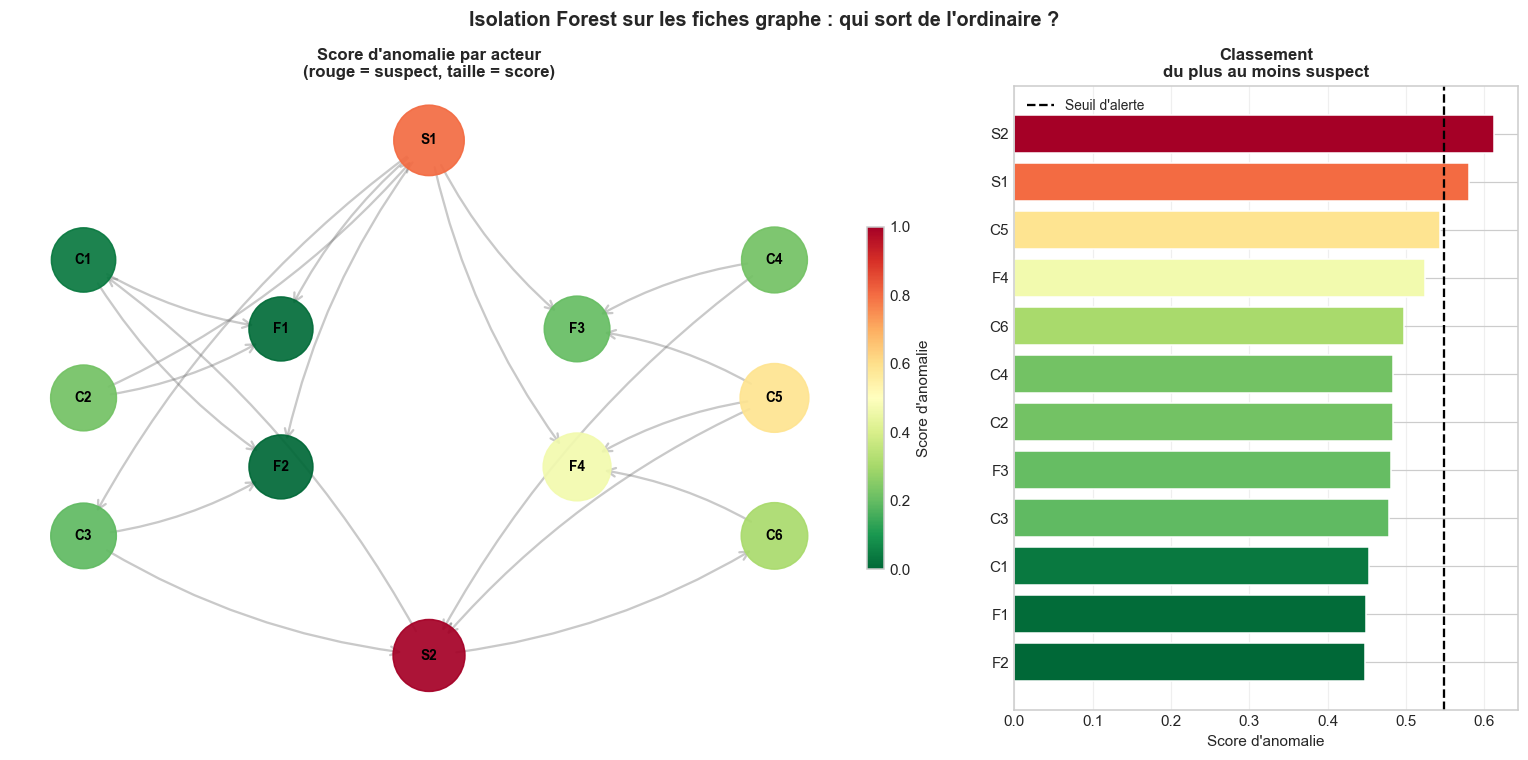

Acteurs avec le score le plus élevé :
  S2   score=0.612  in=3  out=2  betweenness=0.15
  S1   score=0.580  in=1  out=5  betweenness=0.06
  C5   score=0.544  in=0  out=3  betweenness=0.00


In [19]:
from sklearn.preprocessing import StandardScaler

# Réseau synthétique : 10 acteurs normaux + 2 entités suspectes plantées
G_if = nx.DiGraph()

# Transactions normales — chaque client paie 1-2 fournisseurs, sens unique
txn_norm = [
    ('C1', 'F1'), ('C1', 'F2'),
    ('C2', 'F1'),
    ('C3', 'F2'),
    ('C4', 'F3'),
    ('C5', 'F3'), ('C5', 'F4'),
    ('C6', 'F4'),
]

# S1 : paie BEAUCOUP de fournisseurs ET reçoit des paiements ET paie un autre client
# → profil hybride, ni vraiment client ni vraiment fournisseur
txn_s1 = [
    ('C2', 'S1'),                                              # reçoit comme un fournisseur
    ('S1', 'F1'), ('S1', 'F2'), ('S1', 'F3'), ('S1', 'F4'),  # paie comme un client (out-degree élevé)
    ('S1', 'C3'),                                              # paie aussi un client → très anormal
]

# S2 : reçoit de plusieurs clients ET paie d'autres clients → transactions circulaires
txn_s2 = [
    ('C3', 'S2'), ('C4', 'S2'), ('C5', 'S2'),  # reçoit de 3 clients (comme un fournisseur)
    ('S2', 'C1'), ('S2', 'C6'),                 # paie des clients (comme... un client ?)
]

G_if.add_edges_from(txn_norm + txn_s1 + txn_s2)

# Calcul des embeddings — mêmes métriques que partie 5
in_deg_if  = dict(G_if.in_degree())
out_deg_if = dict(G_if.out_degree())
bet_if     = nx.betweenness_centrality(G_if)
close_if   = nx.closeness_centrality(G_if)
pr_if      = nx.pagerank(G_if)
deg_if     = nx.degree_centrality(G_if)

nodes_if = list(G_if.nodes())
feats_if = np.array([
    [in_deg_if[n], out_deg_if[n], deg_if[n], bet_if[n], close_if[n], pr_if[n]]
    for n in nodes_if
])
feats_sc = StandardScaler().fit_transform(feats_if)

# Isolation Forest sur les embeddings graphe
iso_g    = IsolationForest(contamination=0.17, random_state=42)
scores_g = -iso_g.fit(feats_sc).score_samples(feats_sc)   # élevé = suspect

scores_norm_g = (scores_g - scores_g.min()) / (scores_g.max() - scores_g.min())
cmap_if = plt.cm.RdYlGn_r

# Positions manuelles : deux groupes naturels + suspects
pos_if = {
    'C1': (-3.5,  1.5), 'C2': (-3.5,  0.0), 'C3': (-3.5, -1.5),
    'F1': (-1.5,  0.75),'F2': (-1.5, -0.75),
    'C4': ( 3.5,  1.5), 'C5': ( 3.5,  0.0), 'C6': ( 3.5, -1.5),
    'F3': ( 1.5,  0.75),'F4': ( 1.5, -0.75),
    'S1': ( 0.0,  2.8),
    'S2': ( 0.0, -2.8),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})

# --- Réseau coloré par score d'anomalie ---
ax1 = axes[0]
node_colors_if = [cmap_if(scores_norm_g[i]) for i in range(len(nodes_if))]
node_sizes_if  = [500 + scores_g[i] * 2800 for i in range(len(nodes_if))]

nx.draw_networkx_nodes(G_if, pos_if, node_color=node_colors_if,
                       node_size=node_sizes_if, alpha=0.92, ax=ax1)
nx.draw_networkx_labels(G_if, pos_if, font_size=9, font_weight='bold', ax=ax1)
nx.draw_networkx_edges(G_if, pos_if, width=1.5, alpha=0.35, arrowsize=14,
                       edge_color='#666666', arrowstyle='->',
                       connectionstyle='arc3,rad=0.12',
                       min_source_margin=18, min_target_margin=18, ax=ax1)

sm = plt.cm.ScalarMappable(cmap=cmap_if, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax1, shrink=0.55, label="Score d'anomalie", pad=0.02)
ax1.set_title("Score d'anomalie par acteur\n(rouge = suspect, taille = score)",
              fontweight='bold', fontsize=11)
ax1.axis('off')

# --- Classement bar chart ---
ax2 = axes[1]
order_g  = np.argsort(scores_g)[::-1]
n_sorted = [nodes_if[i] for i in order_g]
s_sorted = [scores_g[i]  for i in order_g]
c_sorted = [cmap_if(scores_norm_g[i]) for i in order_g]

ax2.barh(n_sorted[::-1], s_sorted[::-1], color=c_sorted[::-1], edgecolor='white')
ax2.axvline(np.percentile(scores_g, 83), color='black', linestyle='--',
            linewidth=1.5, label="Seuil d'alerte")
ax2.set_xlabel("Score d'anomalie", fontsize=10)
ax2.set_title('Classement\ndu plus au moins suspect', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle("Isolation Forest sur les fiches graphe : qui sort de l'ordinaire ?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Acteurs avec le score le plus élevé :")
for i in order_g[:3]:
    n = nodes_if[i]
    print(f"  {n:3s}  score={scores_g[i]:.3f}  "
          f"in={in_deg_if[n]}  out={out_deg_if[n]}  betweenness={bet_if[n]:.2f}")

### Pourquoi S1 et S2 sont-ils suspects ?

Le score dit **qui** sort de l'ordinaire. En comparant leurs profils aux acteurs normaux, on voit **pourquoi**.

Dans un réseau de paiements légitime, les rôles sont clairs :
- Un **client** envoie de l'argent (out > 0, in = 0)
- Un **fournisseur** reçoit de l'argent (in > 0, out = 0)

S1 et S2 mélangent les deux rôles — c'est ce qui les trahit.

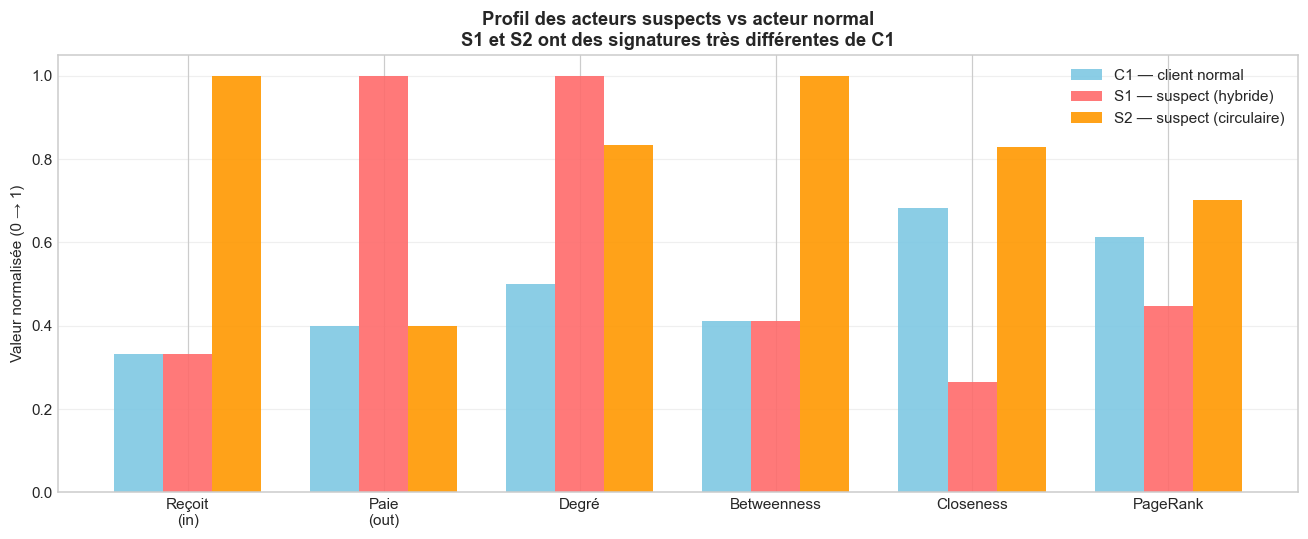

Ce que révèlent les profils :
  C1 : reçoit=1, paie=2 → client classique
  S1 : reçoit=1, paie=5 → ni client ni fournisseur, très connecté
  S2 : reçoit=3, paie=2 → reçoit de clients ET paie des clients = circulaire


In [20]:
# Comparer les profils de S1, S2 et un client normal (C1)
feature_names = ['Reçoit\n(in)', 'Paie\n(out)', 'Degré', 'Betweenness', 'Closeness', 'PageRank']

idx = {n: i for i, n in enumerate(nodes_if)}
# Normaliser pour rendre les barres comparables visuellement
feats_disp = feats_if / (feats_if.max(axis=0) + 1e-10)

x = np.arange(len(feature_names))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, feats_disp[idx['C1']], w, label='C1 — client normal',   color='#7EC8E3', alpha=0.9)
ax.bar(x,     feats_disp[idx['S1']], w, label='S1 — suspect (hybride)', color='#FF6B6B', alpha=0.9)
ax.bar(x + w, feats_disp[idx['S2']], w, label='S2 — suspect (circulaire)', color='#FF9800', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(feature_names, fontsize=10)
ax.set_ylabel('Valeur normalisée (0 → 1)', fontsize=10)
ax.set_title("Profil des acteurs suspects vs acteur normal\n"
             "S1 et S2 ont des signatures très différentes de C1",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Ce que révèlent les profils :")
print(f"  C1 : reçoit={in_deg_if['C1']}, paie={out_deg_if['C1']} → client classique")
print(f"  S1 : reçoit={in_deg_if['S1']}, paie={out_deg_if['S1']} → ni client ni fournisseur, très connecté")
print(f"  S2 : reçoit={in_deg_if['S2']}, paie={out_deg_if['S2']} → reçoit de clients ET paie des clients = circulaire")

### À retenir

> **Isolation Forest transforme chaque acteur en un point dans un espace numérique.**  
> Les points difficiles à classer parmi les autres reçoivent un score élevé.  
> Le score dit **qui** est bizarre — les signaux de la partie 7 diront **pourquoi**.

---

# <a name="partie-7"></a> 7. Application : réseau de paiements

## Du score au signal

Le score Isolation Forest répond à **"qui ?"**.  
Mais un analyste a besoin de savoir **"pourquoi ?"**

C'est le rôle des **signaux d'alerte** : ils traduisent la position inhabituelle dans le graphe en raisons concrètes, lisibles par un humain.

| Ce que mesure le graphe | Ce que dit le signal |
|---|---|
| in-degree ou out-degree anormal | ACTIVITÉ ÉLEVÉE |
| betweenness / closeness élevés | RÉSEAU ATYPIQUE |
| premier lien vers un nœud | NOUVEAU TIERS |
| montant hors distribution historique | MONTANT ANORMAL |
| type d'opération jamais vu | OPÉRATION RARE |
| fournisseur habituel d'un autre client | MAUVAIS DESTINATAIRE |

---

### Les 6 signaux d'alerte

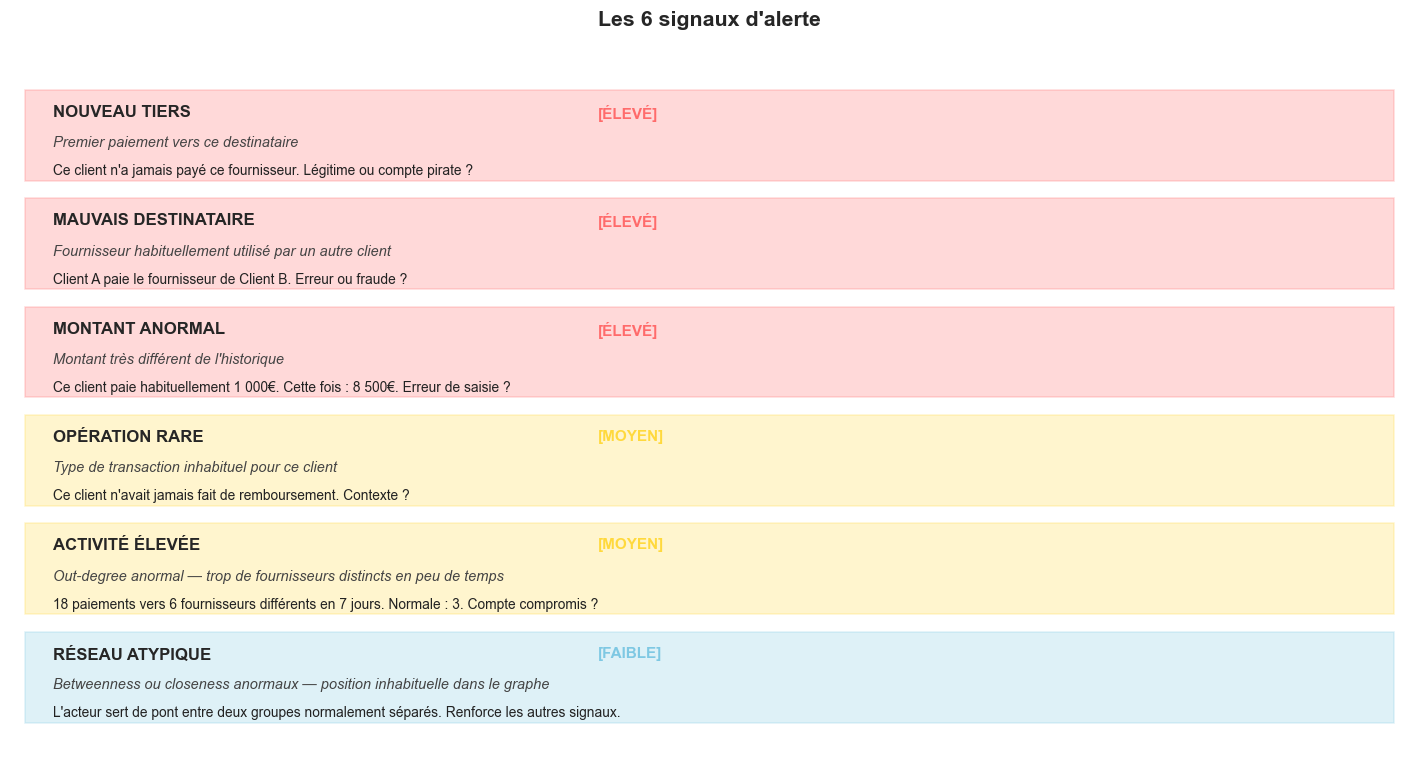

In [21]:
signaux = [
    ('NOUVEAU TIERS',        'ÉLEVÉ',  'Premier paiement vers ce destinataire',
     'Ce client n\'a jamais payé ce fournisseur. Légitime ou compte pirate ?'),
    ('MAUVAIS DESTINATAIRE', 'ÉLEVÉ',  'Fournisseur habituellement utilisé par un autre client',
     'Client A paie le fournisseur de Client B. Erreur ou fraude ?'),
    ('MONTANT ANORMAL',      'ÉLEVÉ',  'Montant très différent de l\'historique',
     'Ce client paie habituellement 1 000€. Cette fois : 8 500€. Erreur de saisie ?'),
    ('OPÉRATION RARE',       'MOYEN',  'Type de transaction inhabituel pour ce client',
     'Ce client n\'avait jamais fait de remboursement. Contexte ?'),
    ('ACTIVITÉ ÉLEVÉE',      'MOYEN',  'Out-degree anormal — trop de fournisseurs distincts en peu de temps',
     '18 paiements vers 6 fournisseurs différents en 7 jours. Normale : 3. Compte compromis ?'),
    ('RÉSEAU ATYPIQUE',      'FAIBLE', 'Betweenness ou closeness anormaux — position inhabituelle dans le graphe',
     'L\'acteur sert de pont entre deux groupes normalement séparés. Renforce les autres signaux.'),
]

couleurs_niveaux = {'ÉLEVÉ': '#FF6B6B', 'MOYEN': '#FFD93D', 'FAIBLE': '#7EC8E3'}

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

y = 0.95
for signal, niveau, desc_courte, explication in signaux:
    couleur = couleurs_niveaux[niveau]
    ax.add_patch(plt.Rectangle((0.01, y-0.14), 0.98, 0.13, transform=ax.transAxes,
                                color=couleur, alpha=0.25, zorder=0))
    ax.text(0.03, y-0.03, f"{signal}", transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.42, y-0.03, f"[{niveau}]", transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=couleur, va='top')
    ax.text(0.03, y-0.075, desc_courte, transform=ax.transAxes,
            fontsize=9.5, va='top', style='italic', color='#444444')
    ax.text(0.03, y-0.115, explication, transform=ax.transAxes,
            fontsize=9, va='top', color='#222222')
    y -= 0.155

ax.set_title("Les 6 signaux d'alerte", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Cas pratique : investigation d'une alerte

Le système remonte une alerte. Voici ce qu'on voit :

In [22]:
# Alerte reçue
alerte = {
    'transaction_id': 'TXN-99821',
    'date':           '2024-11-14',
    'client':         'Client A',
    'fournisseur':    'Fournisseur Z',
    'montant':        25000,
    'type':           'Remboursement',
    'score_anomalie': 0.78,
}

contexte = {
    'historique_montant_moyen': 1200,
    'nb_transactions_precedentes_fournisseur': 0,
    'fournisseur_connu_autres_clients': True,
    'nb_transactions_7_derniers_jours': 3,
    'type_operation_utilise_avant': False,
}

print("=" * 65)
print(f"  RAPPORT D'ALERTE — {alerte['transaction_id']}")
print("=" * 65)
print(f"  Date        : {alerte['date']}")
print(f"  Client      : {alerte['client']}")
print(f"  Fournisseur : {alerte['fournisseur']}")
print(f"  Montant     : {alerte['montant']:,}€  ({alerte['type']})")
print(f"  Score       : {alerte['score_anomalie']} / 1.00  (top 1% le plus suspect)")
print()
print("  SIGNAUX DÉTECTÉS")
print("-" * 65)

signaux_detectes = []

if contexte['nb_transactions_precedentes_fournisseur'] == 0:
    print("  🔴 NOUVEAU TIERS [ÉLEVÉ]")
    print(f"     Jamais payé Fournisseur Z auparavant")
    signaux_detectes.append('ÉLEVÉ')

if contexte['fournisseur_connu_autres_clients']:
    print("  🔴 MAUVAIS DESTINATAIRE [ÉLEVÉ]")
    print(f"     Fournisseur Z est utilisé par d'autres clients — pas par Client A")
    signaux_detectes.append('ÉLEVÉ')

ratio = alerte['montant'] / contexte['historique_montant_moyen']
if ratio > 5:
    print(f"  🔴 MONTANT ANORMAL [ÉLEVÉ]")
    print(f"     {alerte['montant']:,}€ vs moyenne habituelle {contexte['historique_montant_moyen']:,}€ ({ratio:.0f}x plus élevé)")
    signaux_detectes.append('ÉLEVÉ')

if not contexte['type_operation_utilise_avant']:
    print(f"  🟡 OPÉRATION RARE [MOYEN]")
    print(f"     '{alerte['type']}' jamais utilisé par Client A")
    signaux_detectes.append('MOYEN')

n_eleve = signaux_detectes.count('ÉLEVÉ')
n_moyen = signaux_detectes.count('MOYEN')

print()
print("=" * 65)
if n_eleve >= 2:
    print("  RECOMMANDATION : BLOQUER ET INVESTIGUER EN URGENCE")
    print(f"  {n_eleve} signaux ÉLEVÉS détectés simultanément")
elif n_eleve == 1:
    print("  RECOMMANDATION : Investigation recommandée")
print("=" * 65)
print()
print("  ACTIONS SUGGÉRÉES")
print("  1. Vérifier si Fournisseur Z est dans la base fournisseurs validés")
print("  2. Contacter Client A pour confirmer la transaction")
print("  3. Vérifier les documents (facture, bon de commande)")
print("  4. Si fraude confirmée → bloquer et escalader")
print("  5. Si légitime → valider et mettre à jour le profil")

  RAPPORT D'ALERTE — TXN-99821
  Date        : 2024-11-14
  Client      : Client A
  Fournisseur : Fournisseur Z
  Montant     : 25,000€  (Remboursement)
  Score       : 0.78 / 1.00  (top 1% le plus suspect)

  SIGNAUX DÉTECTÉS
-----------------------------------------------------------------
  🔴 NOUVEAU TIERS [ÉLEVÉ]
     Jamais payé Fournisseur Z auparavant
  🔴 MAUVAIS DESTINATAIRE [ÉLEVÉ]
     Fournisseur Z est utilisé par d'autres clients — pas par Client A
  🔴 MONTANT ANORMAL [ÉLEVÉ]
     25,000€ vs moyenne habituelle 1,200€ (21x plus élevé)
  🟡 OPÉRATION RARE [MOYEN]
     'Remboursement' jamais utilisé par Client A

  RECOMMANDATION : BLOQUER ET INVESTIGUER EN URGENCE
  3 signaux ÉLEVÉS détectés simultanément

  ACTIONS SUGGÉRÉES
  1. Vérifier si Fournisseur Z est dans la base fournisseurs validés
  2. Contacter Client A pour confirmer la transaction
  3. Vérifier les documents (facture, bon de commande)
  4. Si fraude confirmée → bloquer et escalader
  5. Si légitime → valider e

---

## Ce qu'on a appris dans ce notebook

| Partie | Concept | Ce que ça permet |
|---|---|---|
| 1 | Graphes (nœuds, arêtes, direction, poids) | Représenter les relations entre acteurs |
| 2 | Navigation, chemins, composantes connexes | Trouver des connexions cachées |
| 3 | Centralité (degree, betweenness, PageRank) | Identifier les acteurs importants |
| 4 | Détection de communautés | Repérer des groupes coordonnés |
| 5 | Embeddings (fiches numériques) | Transformer le graphe en données machine |
| 6 | Isolation Forest sur les embeddings | Scorer les acteurs dont le profil sort de l'ordinaire |
| 7 | Signaux d'alerte | Expliquer en langage humain pourquoi un acteur est suspect |

---

> **Le pipeline complet :**
> ```
> Transactions → Graphe → Métriques → Embeddings → Score IF → Signaux → Investigation
> ```
>
> Un tableau de transactions est plat. Un graphe révèle la **structure** — qui est connecté à qui, comment, à quelle intensité.  
> C'est cette structure qui rend visible ce qui serait invisible ligne par ligne.